# Running the Notebook

This notebook is organized into several sections:

1. **Imports and Robot Configuration**: Sets up required packages and defines all robot parameters.
2. **Kinematics and Motion Planning**: Implements and explains the kinematic models used for the robot and its actuators.
3. **Trajectory Generation**: Details the generation of end-effector trajectories using modern robotics tools.
4. **Feedback Control**: Calculates velocity commands based on a feedforward-plus-PI control law.
5. **Simulation and Visualization**: Runs the robot simulation and visualizes results with plots.

To run this notebook successfully, ensure you have the following Python packages installed:

- `numpy`
- `matplotlib`
- `modern_robotics` (from the Modern Robotics library, available via pip or GitHub)

You can install any missing packages with pip, for example:

```bash
 pip install numpy matplotlib modern_robotics
```


# Imports and Robot Configuration


In [3]:
import modern_robotics as mr
import numpy as np
import matplotlib.pyplot as plt

# Max velocity of wheels/joints
vmax = 10

# Dimensions from Figure 13.5 and Exercise 13.33
l = 0.47 / 2  # distance between body frame and wheel axis (m)
w = 0.3 / 2  # distance between center of wheel axis and middle of wheel (m)
r = 0.0475  # wheel radius (m)
# Chassis kinematics matrix (Eq 13.33) - maps wheel velocities to body twist
F = (r / 4) * np.array(
    [
        [-1 / (l + w), 1 / (l + w), 1 / (l + w), -1 / (l + w)],
        [1, 1, 1, 1],
        [-1, 1, -1, 1],
    ],
    dtype=np.float32,
)

# Body screw axes of the arm in the {0} frame
Blist = np.array(
    [
        [0, 0, 1, 0, 0.033, 0],
        [0, -1, 0, -0.5076, 0, 0],
        [0, -1, 0, -0.3526, 0, 0],
        [0, -1, 0, -0.2176, 0, 0],
        [0, 0, 1, 0, 0, 0],
    ]
).T

# Given transformations from Figure 13.25 and Exercise 13.33
M_0e = np.array([[1, 0, 0, 0.0330], [0, 1, 0, 0], [0, 0, 1, 0.6546], [0, 0, 0, 1]])
T_b0 = np.array([[1, 0, 0, 0.1662], [0, 1, 0, 0], [0, 0, 1, 0.0026], [0, 0, 0, 1]])
T_sbi = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0.0963], [0, 0, 0, 1]])
T_0ei = np.array([[0, 0, 1, 0.033], [0, 1, 0, 0], [-1, 0, 0, 0.6546], [0, 0, 0, 1]])

# End effector configurations for trajectory generation
T_sei = T_sbi @ T_b0 @ T_0ei
# Cube poses in space frame: initial and goal
T_sci = np.array([[1, 0, 0, 1], [0, 1, 0, 0], [0, 0, 1, 0.025], [0, 0, 0, 1]])
T_scf = np.array([[0, 1, 0, 0], [-1, 0, 0, -1], [0, 0, 1, 0.025], [0, 0, 0, 1]])

# Gripper is angled 135 degrees relative to the cube y axis
theta_grasp = np.deg2rad(135)
T_ceg = np.array(
    [
        [np.cos(theta_grasp), 0.0, np.sin(theta_grasp), 0.0],
        [0.0, 1.0, 0.0, 0.0],
        [-np.sin(theta_grasp), 0.0, np.cos(theta_grasp), 0.0],
        [0.0, 0.0, 0.0, 1.0],
    ]
)
T_ces = np.array(
    [
        [np.cos(theta_grasp), 0.0, np.sin(theta_grasp), 0.0],
        [0.0, 1.0, 0.0, 0.0],
        [-np.sin(theta_grasp), 0.0, np.cos(theta_grasp), 0.05],
        [0.0, 0.0, 0.0, 1.0],
    ]
)

# Simulation parameters
Tf = 4
method = 5  # quintic polynomial for ScrewTrajectory (smooth start/stop)
dt = 0.01

# Component 1: Kinematics Simulator


In [4]:
def NextState(x, u, dt, vmax) -> np.ndarray:
    """
    First-order Euler step to compute the next state of the robot given the current state, joint/wheel velocities, and time step.

    Parameters:
        x (np.ndarray): Current state of the robot (12 variables: 3 for chassis, 5 for arm, 4 for wheel angles).
        u (np.ndarray): Joint and wheel velocities (9 variables: 4 for wheels, 5 for arm joints (joint_velocities)).
        dt (float): Timestep size (Δt).
        vmax (float): Maximum wheel velocity magnitude.

    Returns:
        x_next (np.ndarray): Next state of the robot as a 12-element array, concatenated in the following order:
            - chassis configuration (3 variables)
            - arm joint angles (5 variables)
            - wheel angles (4 variables)
    """
    # Ensure joint and wheel velocities are within the allowed limits
    u = np.clip(u, -vmax, vmax)

    # Extract the current state of the robot
    q_k = x[:3]
    phi_k = x[0]
    arm_state = x[3:8]
    wheel_state = x[8:]

    # Extract the joint and wheel velocities
    joint_velocities = u[4:]
    wheel_velocities = u[:4]

    # Calculate the body twist (Equation 13.33)
    delta_theta = wheel_velocities * dt
    F = (r / 4) * np.array(
        [
            [-1 / (l + w), 1 / (l + w), 1 / (l + w), -1 / (l + w)],
            [1, 1, 1, 1],
            [-1, 1, -1, 1],
        ]
    )
    V_b = F @ delta_theta
    w_bz = V_b[0]
    v_bx = V_b[1]
    v_by = V_b[2]

    # Calculate the change in coordinates relative to the body frame (Equation 13.35)
    if w_bz == 0:
        delta_qb = np.array([0, v_bx, v_by])
    else:
        delta_qb = np.array(
            [
                w_bz,
                (v_bx * np.sin(w_bz) + v_by * (np.cos(w_bz) - 1)) / w_bz,
                (v_by * np.sin(w_bz) + v_bx * (1 - np.cos(w_bz))) / w_bz,
            ]
        )

    # Update odometry (Equation 13.36)
    delta_q = (
        np.array(
            [
                [1, 0, 0],
                [0, np.cos(phi_k), -np.sin(phi_k)],
                [0, np.sin(phi_k), np.cos(phi_k)],
            ]
        )
        @ delta_qb
    )
    chassis_next_state = q_k + delta_q

    # Update joint and wheel states
    arm_next_state = arm_state + dt * joint_velocities
    wheel_next_state = wheel_state + dt * wheel_velocities

    # Next state of the robot
    x_next = np.concatenate([chassis_next_state, arm_next_state, wheel_next_state])

    return x_next

### Sanity Check for NextState


In [5]:
# [wheel1, wheel2, wheel3, wheel4, arm_j1, j2, j3, j4, j5] - constant velocities for testing
constant_control = np.array([0.2, 0.2, 0.2, 0.2, 0.2, 10, -10, 10, -10])
dt = 0.01

x = np.zeros(12)
trajectory = []

for i in range(100):
    x = NextState(x, constant_control, dt, vmax)
    # Append gripper state (0 = open) for CoppeliaSim CSV format
    trajectory.append(np.concatenate([x, [0]]))

trajectory = np.array(trajectory)

np.savetxt("trajectories/component_1_trajectory.csv", trajectory, delimiter=",")

# Component 2: Reference Trajectory Generator


In [6]:
def FlattenAndAddGripperState(T_se_list, gripper_state) -> np.ndarray:
    """
    Flattens a list of 4x4 SE(3) matrices into a (N, 13) array in the order:
    [r_11, r_12, r_13, r_21, r_22, r_23, r_31, r_32, r_33, p_x, p_y, p_z, gripper_state],
    where r_ij are the rotation matrix entries and p_x, p_y, p_z are the translation components.

    Parameters:
        T_se_list (list): A list of 4x4 SE(3) matrices.
        gripper_state (int): The gripper state (0 or 1).

    Returns:
        np.ndarray: A (N, 13) array where each row contains the configuration of the end-effector at a point in the trajectory.
    """
    T_se_arr = np.asarray(T_se_list)
    r = T_se_arr[:, 0:3, 0:3].reshape(T_se_arr.shape[0], 9)
    p = T_se_arr[:, 0:3, 3]
    gripper = np.full((T_se_arr.shape[0], 1), gripper_state)
    return np.concatenate([r, p, gripper], axis=1)


def UnflattenAndRemoveGripperState(traj) -> np.ndarray:
    """
    Takes a (13,) array (as produced by FlattenAndAddGripperState for one SE(3) transformation)
    and converts it into a 4x4 SE(3) matrix (rotation and translation), discarding the gripper state.

    Parameters:
        traj (np.ndarray): A (13,) array [r_11, ..., r_33, p_x, p_y, p_z, gripper_state]

    Returns:
        np.ndarray: A 4x4 SE(3) transformation matrix.
    """
    R = traj[0:9].reshape(3, 3)
    p = traj[9:12].reshape(3, 1)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3:] = p
    return T


def TrajectoryGenerator(T_sei, T_sci, T_scf, T_ceg, T_ces, k):
    """
    Generates a concatenated reference trajectory for the end-effector to move a cube.

    This function creates the reference (desired) trajectory for the end-effector frame {e} to move a cube
    from an initial configuration to a specified goal configuration using a sequence of eight concatenated
    trajectory segments. Each segment begins and ends at rest. Each trajectory configuration is represented
    as a 13-variable array:
        [r_11, r_12, r_13, r_21, r_22, r_23, r_31, r_32, r_33, p_x, p_y, p_z, gripper_state]

    Parameters:
        T_sei : np.ndarray
            The initial configuration of the end-effector (4x4 SE(3)).
        T_sci : np.ndarray
            The initial configuration of the cube (4x4 SE(3)).
        T_scf : np.ndarray
            The final (goal) configuration of the cube (4x4 SE(3)).
        T_ceg : np.ndarray
            The configuration of the end-effector relative to the cube when grasping (4x4 SE(3)).
        T_ces : np.ndarray
            The standoff configuration of the end-effector relative to the cube before or after grasping (4x4 SE(3)).
        k : int
            The number of trajectory reference configurations per 0.01 seconds (>=1).
        Tf : int
            The number of seconds the trajectory takes to complete.

    Returns:
        traj : np.ndarray
            An (N, 13) array where each row contains the configuration of the end-effector at a point in the trajectory.
        The 13 variables per configuration are [r_11, r_12, r_13, r_21, r_22, r_23, r_31, r_32, r_33, p_x, p_y, p_z, gripper_state].
        The trajectory contains N configurations representing the entire pick-and-place motion sequence.
    """
    # Trajectory sequence as described in the project:
    # 1. Move the gripper from its initial configuration to a "standoff" configuration a few cm above the block.
    # 2. Move the gripper down to the grasp position.
    # 3. Close the gripper.
    # 4. Move the gripper back up to the "standoff" configuration.
    # 5. Move the gripper to a "standoff" configuration above the final configuration.
    # 6. Move the gripper to the final configuration of the object.
    # 7. Open the gripper.
    # 8. Move the gripper back to the "standoff" configuration above the final location.
    # Number of reference configs per segment (e.g. k=10, Tf=4 → 4000 configs per segment)
    N = Tf * k / 0.01

    # Trajectory segments
    T_1 = FlattenAndAddGripperState(
        mr.ScrewTrajectory(T_sei, T_sci @ T_ces, Tf, N, method), 0
    )

    T_2_init = UnflattenAndRemoveGripperState(T_1[-1])
    T_2 = FlattenAndAddGripperState(
        mr.ScrewTrajectory(T_2_init, T_sci @ T_ceg, Tf, N, method), 0
    )

    # Hold gripper closed for 63 timesteps (~0.63s) so CoppeliaSim has time to fully close
    T_3 = T_2[-1].copy()
    T_3[-1] = 1
    T_3 = np.tile(T_3.reshape(1, -1), (63, 1))

    T_4_init = UnflattenAndRemoveGripperState(T_3[-1])
    T_4 = FlattenAndAddGripperState(
        mr.ScrewTrajectory(T_4_init, T_sci @ T_ces, Tf, N, method), 1
    )

    T_5_init = UnflattenAndRemoveGripperState(T_4[-1])
    T_5 = FlattenAndAddGripperState(
        mr.ScrewTrajectory(T_5_init, T_scf @ T_ces, Tf, N, method), 1
    )

    T_6_init = UnflattenAndRemoveGripperState(T_5[-1])
    T_6 = FlattenAndAddGripperState(
        mr.ScrewTrajectory(T_6_init, T_scf @ T_ceg, Tf, N, method), 1
    )

    # Hold gripper open for 63 timesteps (~0.63s) so CoppeliaSim has time to fully open
    T_7 = T_6[-1].copy()
    T_7[-1] = 0
    T_7 = np.tile(T_7.reshape(1, -1), (63, 1))

    T_8_init = UnflattenAndRemoveGripperState(T_7[-1])
    T_8 = FlattenAndAddGripperState(
        mr.ScrewTrajectory(T_8_init, T_scf @ T_ces, Tf, N, method), 0
    )

    # Concatenate trajectory segments
    traj = np.concatenate([T_1, T_2, T_3, T_4, T_5, T_6, T_7, T_8], axis=0)

    # Write trajectories to .csv file
    np.savetxt("trajectories/component_2_trajectory.csv", traj, delimiter=",")

    return traj


test_trajectory = TrajectoryGenerator(T_sei, T_sci, T_scf, T_ceg, T_ces, 10)

# Component 3: Feedforward Plus Feedback Control


In [ ]:
def FeedbackControl(
    X, X_d, X_dnext, K_p, K_i, dt, integral_error, thetalist, F, Blist, pinv_tol=1e-2
):
    """
    Calculates the task-space feedforward plus feedback control law for
    tracking a desired end-effector trajectory.

    Inputs:
        X (np.ndarray): The current actual end-effector configuration (T_se, 4x4 SE(3)).
        X_d (np.ndarray): The current reference (desired) end-effector configuration (T_se,desired, 4x4 SE(3)).
        X_dnext (np.ndarray): The reference end-effector configuration at the next timestep
            (T_se,desired_next, 4x4 SE(3)).
        K_p (np.ndarray): The proportional gain matrix (6x6).
        K_i (np.ndarray): The integral gain matrix (6x6).
        dt (float): The timestep Δt between trajectory configurations.
        integral_error (np.ndarray): The integral error of the end-effector twist, accumulated over time.
        thetalist (np.ndarray): The current actual configuration of the arm joints (5x1).
        F (np.ndarray): The forward kinematics matrix for the chassis.
        Blist (np.ndarray): The screw axes for the arm in the {b} frame (6x5).
        pinv_tol (float): The tolerance for the pinv function.

    Outputs:
        V (np.ndarray):
            The commanded end-effector twist V, expressed in the end-effector frame {e} (6x1).
            This can be used for plotting purposes.
        X_err (np.ndarray):

            The error between the current and desired end-effector configurations. Used for plotting purposes.
        controls (tuple):
            A tuple containing:
                - The commanded wheel speeds (4x1 array)
                - The commanded arm joint speeds, θ̇ (5x1 array)
        integral_error (np.ndarray):
            The integral error of the end-effector twist, accumulated over time.

    """

    # Calculate feedforward reference twist
    V_d = mr.se3ToVec(mr.MatrixLog6(np.dot(mr.TransInv(X_d), X_dnext))) / dt

    # Calculate error twist
    X_err_se3mat = mr.MatrixLog6(np.dot(mr.TransInv(X), X_d))
    X_err = mr.se3ToVec(X_err_se3mat)

    # Update integral error
    integral_error += X_err * dt

    # Feedback twist: Adjoint transforms V_d into current frame, then add P and I terms
    V = (
        mr.Adjoint(np.dot(mr.TransInv(X), X_d)) @ V_d
        + K_p @ X_err
        + K_i @ integral_error
    )

    # Base Jacobian (Section 13.5): chassis affects yaw + x,y velocity, so we pad F into 6 rows
    F6 = np.zeros((6, 4))
    F6[2:5, :] = F
    T_0e = mr.FKinBody(M_0e, Blist, thetalist)
    J_base = mr.Adjoint(mr.TransInv(T_0e) @ mr.TransInv(T_b0)) @ F6

    # Calculate the arm Jacobian using the body screw axes of the arm
    J_arm = mr.JacobianBody(Blist, thetalist)

    # Calculate the full Jacobian
    J_e = np.concatenate((J_base, J_arm), axis=1)

    # Damped least-squares: 1e-2 avoids blowing up near singularities
    controls = np.linalg.pinv(J_e, pinv_tol) @ V

    return V, X_err, J_e, controls, integral_error

### Sanity Check for FeedbackControl


In [15]:
import numpy as np

# Initial configuration: φ, x, y, θ1, θ2, θ3, θ4, θ5
robot_config = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.2, -1.6, 0.0])

X_d = np.array([[0, 0, 1, 0.5], [0, 1, 0, 0], [-1, 0, 0, 0.5], [0, 0, 0, 1]])

# X_d_next: Desired configuration of end-effector at next time-step
X_d_next = np.array([[0, 0, 1, 0.6], [0, 1, 0, 0], [-1, 0, 0, 0.3], [0, 0, 0, 1]])

# X: Actual current configuration (calculated for current robot_config)
X = np.array(
    [[0.170, 0, 0.985, 0.387], [0, 1, 0, 0], [-0.985, 0, 0.170, 0.570], [0, 0, 0, 1]]
)

# K_p = identity, K_i = zero (matches the second test case in the project PDF)
K_p = np.zeros((6, 6))
K_i = np.zeros((6, 6))

# For this test, assume V_d = 0 since X_d, X_d_next are fixed poses (static target)
V_d = np.zeros(6)
integral_error = np.zeros(6)

# thetalist: Current joint angles for the arm (5,)
thetalist = robot_config[3:]

# Run with no pinv tolerance to get the same results as the project PDF
pinv_tol = None
V, X_err, J_e, controls, integral_error = FeedbackControl(
    X=X,
    X_d=X_d,
    X_dnext=X_d_next,
    K_p=K_p,
    K_i=K_i,
    dt=dt,
    integral_error=integral_error,
    F=F,
    Blist=Blist,
    thetalist=thetalist,
    pinv_tol=pinv_tol,
)

print("--- K_p = 0 ---")
print("Final V (twist):", V)
print("Final controls (wheel/arm velocities):", controls)
print("Final J_e (Jacobian):", J_e)

# Now run test with identity K_p
K_p = np.eye(6)
V, X_err, J_e, controls, integral_error = FeedbackControl(
    X=X,
    X_d=X_d,
    X_dnext=X_d_next,
    K_p=K_p,
    K_i=K_i,
    dt=dt,
    integral_error=integral_error,
    F=F,
    Blist=Blist,
    thetalist=thetalist,
    pinv_tol=pinv_tol,
)
print("\n--- K_p = identity ---")
print("Final V (twist):", V)
print("Final controls (wheel/arm velocities):", controls)
print("Final J_e (Jacobian):", J_e)

--- K_p = 0 ---
Final V (twist): [ 0.    0.    0.   21.4   0.    6.45]
Final controls (wheel/arm velocities): [ 1.57106803e+02  1.57106803e+02  1.57106803e+02  1.57106803e+02
 -1.92748043e-13 -6.52620420e+02  1.39803683e+03 -7.45416408e+02
  9.00198157e-15]
Final J_e (Jacobian): [[ 3.03953649e-02 -3.03953649e-02 -3.03953649e-02  3.03953649e-02
  -9.85449730e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
   0.00000000e+00]
 [-5.24249302e-03  5.24249302e-03  5.24249302e-03 -5.24249302e-03
   1.69967143e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00]
 [ 2.01835980e-03  2.01835980e-03  2.01835980e-03  2.01835980e-03
   0.00000000e+00 -2.40002972e-01 -2.13658064e-01 -2.17600000e-01
   0.00000000e+00]
 [-2.38059357e-02  2.38059357e-02  5.59360185e-05 -5.59360185e-05
   2.20613502e-01  0.00000000e+00  0.00000000e+00 

# Component 4: Full Program/Wrapper Script


In [ ]:
def T_sb(phi, x, y):
    """Body frame {b} relative to space frame {s} from chassis pose (phi, x, y)."""
    return np.array(
        [
            [np.cos(phi), -np.sin(phi), 0, x],
            [np.sin(phi), np.cos(phi), 0, y],
            [0, 0, 1, 0.0963],
            [0, 0, 0, 1],
        ]
    )


def T_be(thetalist):
    """End-effector frame {e} relative to body frame {b} from arm joint angles."""
    T_0e = mr.FKinBody(M_0e, Blist, thetalist)
    return T_b0 @ T_0e


def T_se(phi, x, y, thetalist):
    """End-effector frame {e} in space frame {s} - full forward kinematics."""
    return T_sb(phi, x, y) @ T_be(thetalist)


def run_simulation(actual_init_config, T_sei, T_sci, T_scf, K_p, K_i, k):
    """Run the full pick-and-place: generate trajectory, then sense→control→actuate loop."""
    trajectory = TrajectoryGenerator(T_sei, T_sci, T_scf, T_ceg, T_ces, k)
    q_traj = []
    X_err_traj = []
    J_e_traj = []
    integral_error = np.zeros(6)

    # Set initial robot configuration
    q = actual_init_config
    q_traj.append(q)

    for i in range(len(trajectory) - 1):
        # Sense: get actual EE pose from current state
        thetalist = q[3:8]
        X = T_se(q[0], q[1], q[2], thetalist)
        X_d = UnflattenAndRemoveGripperState(trajectory[i])
        X_d_next = UnflattenAndRemoveGripperState(trajectory[i + 1])

        # Control: compute wheel/arm velocities
        V, X_err, J_e, controls, integral_error = FeedbackControl(
            X, X_d, X_d_next, K_p, K_i, dt, integral_error, thetalist, F, Blist
        )

        # Actuate: NextState expects 12 vars (no gripper), so q[:-1]
        q = NextState(q[:-1], controls, dt, vmax)
        q = np.concatenate([q, [trajectory[i, -1]]])  # tack gripper state back on

        # Downsample for plotting (every k-th step)
        if i % k == 0:
            q_traj.append(q)
            X_err_traj.append(X_err)
            J_e_traj.append(J_e)

    return np.array(q_traj), np.array(X_err_traj), np.array(J_e_traj)


def _apply_common_axis_style(ax):
    """Shared styling for plot axes (grid, background, hide top/right spines)."""
    ax.grid(True, alpha=0.25, linestyle=":")
    ax.set_facecolor("#FAFAFA")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_X_err_traj(X_err_traj, fname, case_name):
    fig, axes = plt.subplots(2, 3, figsize=(13, 6.8), sharex=True)
    time = np.arange(X_err_traj.shape[0]) * dt

    labels = [
        r"$\omega_{\mathrm{err},x}$",
        r"$\omega_{\mathrm{err},y}$",
        r"$\omega_{\mathrm{err},z}$",
        r"$v_{\mathrm{err},x}$",
        r"$v_{\mathrm{err},y}$",
        r"$v_{\mathrm{err},z}$",
    ]
    colors = ["#4C78A8", "#59A14F", "#E15759", "#F28E2B", "#B07AA1", "#76B7B2"]

    for i, ax in enumerate(axes.flat):
        ax.plot(time, X_err_traj[:, i], color=colors[i], linewidth=2)
        ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

        ax.set_title(labels[i], fontsize=12, pad=8)
        if i >= 3:
            ax.set_xlabel("Time (s)")
        ax.set_ylabel("Error")
        _apply_common_axis_style(ax)

    fig.suptitle(
        f"{case_name} - End-Effector Twist Error Components",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig(f"plots/{fname}.png", dpi=300, bbox_inches="tight")


def plot_manipulability_factors(J_e_traj, fname, case_name):
    """Plot manipulability (condition number) for angular vs linear velocity over time."""
    # Split Jacobian: rows 0-2 = angular velocity, 3-5 = linear velocity
    J_w = J_e_traj[:, :3, :]
    J_v = J_e_traj[:, 3:, :]

    # A = J @ J^T for manipulability ellipsoid; eigenvalues give axis lengths
    A_w = J_w @ np.transpose(J_w, (0, 2, 1))
    A_v = J_v @ np.transpose(J_v, (0, 2, 1))

    A_w_eigvals = np.linalg.eigvals(A_w)
    A_v_eigvals = np.linalg.eigvals(A_v)
    eigval_max_w, eigval_min_w = np.max(A_w_eigvals, axis=1), np.min(
        A_w_eigvals, axis=1
    )
    eigval_max_v, eigval_min_v = np.max(A_v_eigvals, axis=1), np.min(
        A_v_eigvals, axis=1
    )

    # Condition number: sqrt(max/min) - high means near singularity, poor manipulability
    mu_w = np.sqrt(eigval_max_w) / np.sqrt(eigval_min_w)
    mu_v = np.sqrt(eigval_max_v) / np.sqrt(eigval_min_v)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
    time = np.arange(J_e_traj.shape[0]) * dt

    axes[0].plot(time, mu_w, color="#4C78A8", linewidth=2)
    axes[0].axhline(1, color="black", linestyle="--", linewidth=1, alpha=0.5)
    axes[0].set_title(r"$\mu_\omega$", fontsize=12, pad=8)
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel(r"$\sqrt{\lambda_{\max}/\lambda_{\min}}$")
    _apply_common_axis_style(axes[0])

    axes[1].plot(time, mu_v, color="#F28E2B", linewidth=2)
    axes[1].axhline(1, color="black", linestyle="--", linewidth=1, alpha=0.5)
    axes[1].set_title(r"$\mu_v$", fontsize=12, pad=8)
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel(r"$\sqrt{\lambda_{\max}/\lambda_{\min}}$")
    _apply_common_axis_style(axes[1])

    fig.suptitle(
        f"{case_name} - End-Effector Manipulability Factors Over Time",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig(f"plots/{fname}.png", dpi=300, bbox_inches="tight")

### Best Case

Nominal gains (K_p=1.5, K_i=0) — robot starts near the reference trajectory and tracks it well.


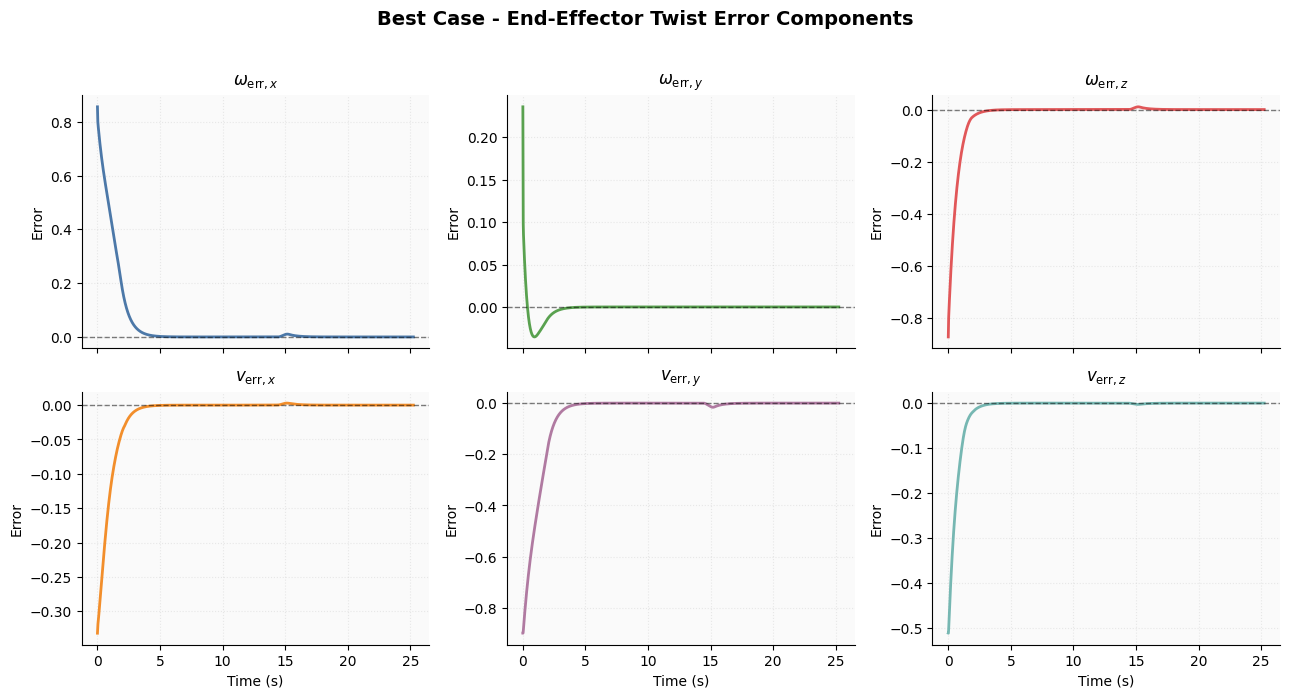

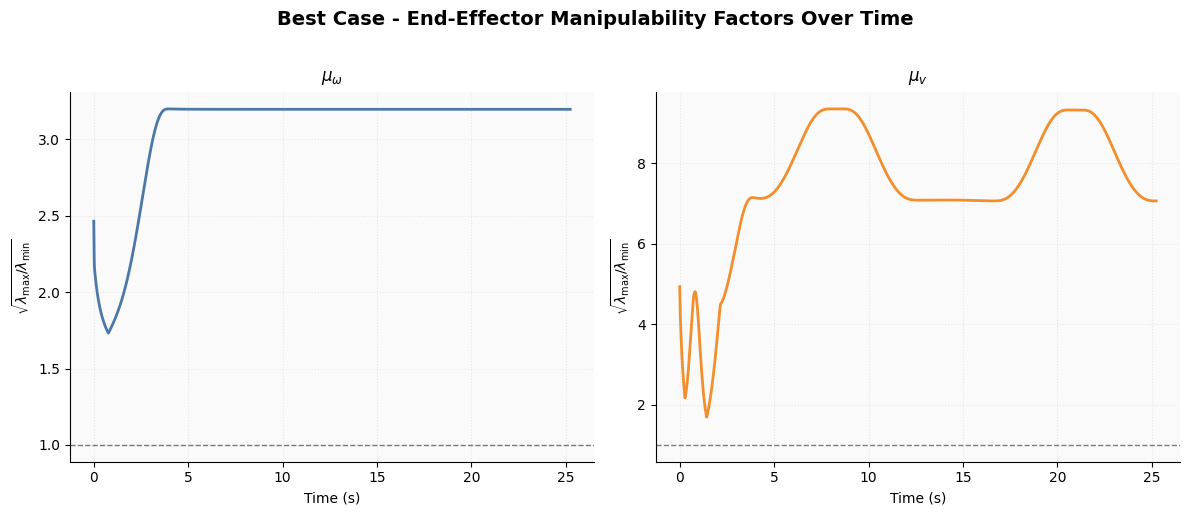

In [10]:
# [phi, x, y, theta1..5, wheel1..4, gripper] — 13 vars for CoppeliaSim
actual_init_config = np.array(
    [0.25, -0.25, 0.820, 0.459, -0.227, 0.482, -1.294, 0.731, 0, 0, 0, 0, 0]
)
# Reference EE pose that trajectory is generated from (where we *want* to start)
T_se_ref = np.array([[0, 0, 1, 0], [0, 1, 0, 0], [-1, 0, 0, 0.5], [0, 0, 0, 1]])

# Controller gains
K_p = 1.5 * np.eye(6)
K_i = np.zeros((6, 6))

# Run simulation and plotting
q_traj, X_err_traj, J_e_traj = run_simulation(
    actual_init_config, T_se_ref, T_sci, T_scf, K_p, K_i, k=1
)


np.savetxt("trajectories/best_case_trajectory.csv", q_traj, delimiter=",")
plot_X_err_traj(X_err_traj, "best_case_X_err_traj", "Best Case")
plot_manipulability_factors(J_e_traj, "best_case_manipulability_factors", "Best Case")

### Overshoot Case

Higher gains (K_p=4, K_i=0.01) — faster correction but more overshoot and oscillation.


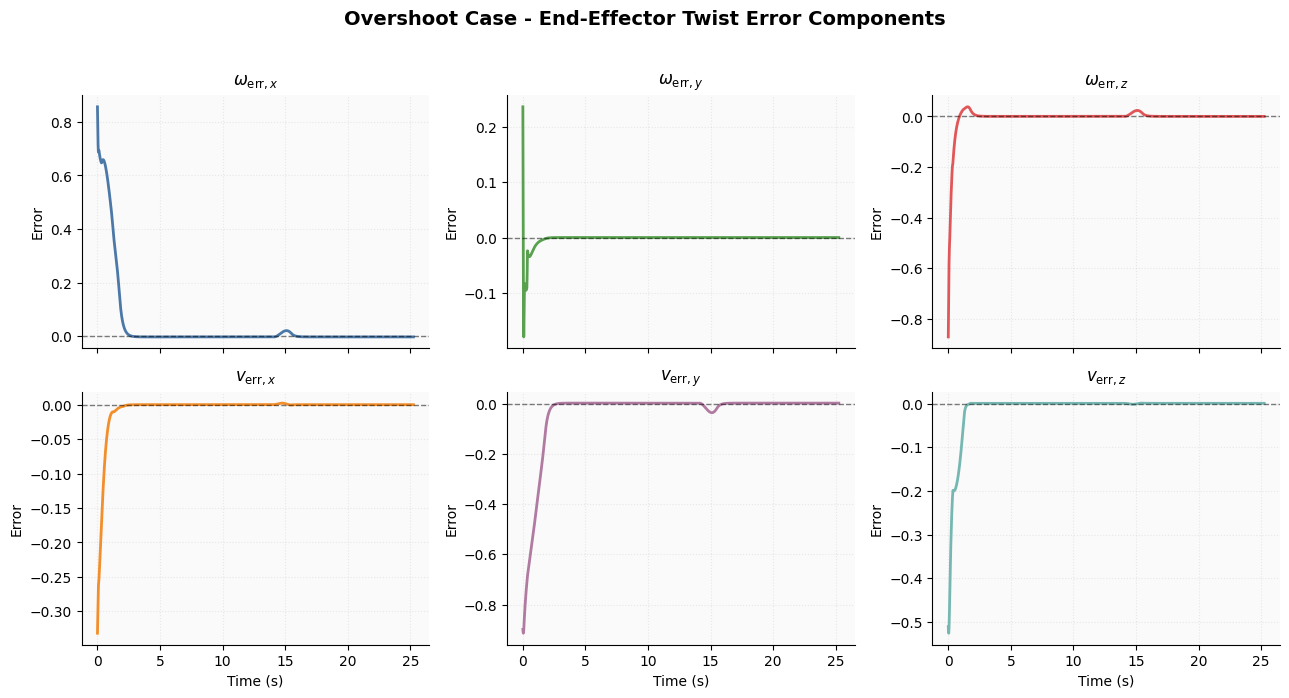

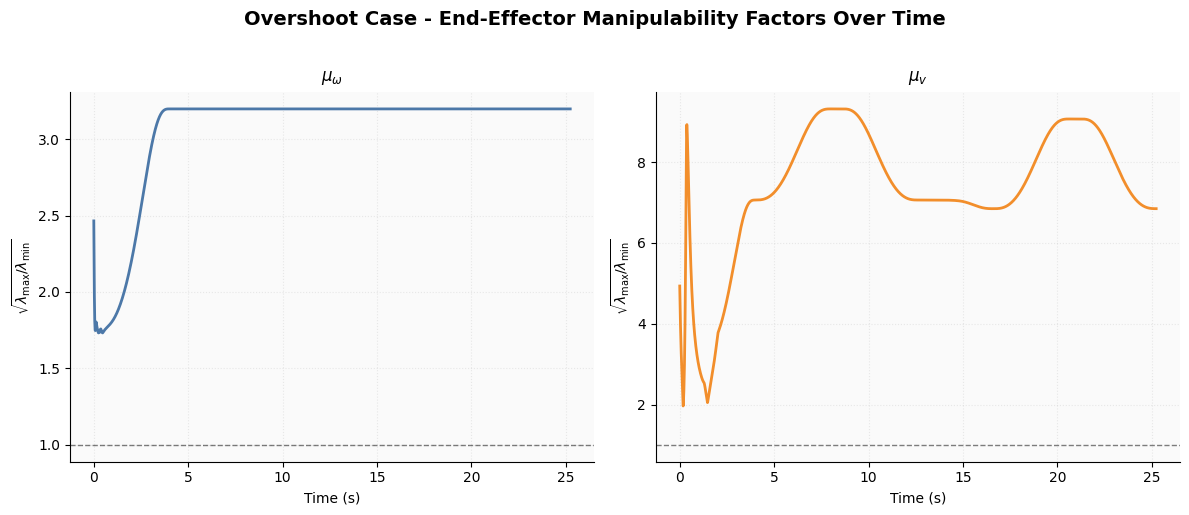

In [11]:
# Same initial state as best case — we're just cranking up the gains
actual_init_config = np.array(
    [0.25, -0.25, 0.820, 0.459, -0.227, 0.482, -1.294, 0.731, 0, 0, 0, 0, 0]
)
T_se_ref = np.array([[0, 0, 1, 0], [0, 1, 0, 0], [-1, 0, 0, 0.5], [0, 0, 0, 1]])

# Controller gains
K_p = 4 * np.eye(6)
K_i = 0.01 * np.eye(6)

# Run simulation and plotting
q_traj, X_err_traj, J_e_traj = run_simulation(
    actual_init_config, T_se_ref, T_sci, T_scf, K_p, K_i, k=1
)
np.savetxt("trajectories/overshoot_case_trajectory.csv", q_traj, delimiter=",")
plot_X_err_traj(X_err_traj, "overshoot_case_X_err_traj", "Overshoot Case")
plot_manipulability_factors(
    J_e_traj, "overshoot_case_manipulability_factors", "Overshoot Case"
)

### New Task

Same robot, different cube start/goal — cube starts at (0.82, 1.5, 0.5) and ends at (2.63, -1, 0.75), with different orientations.


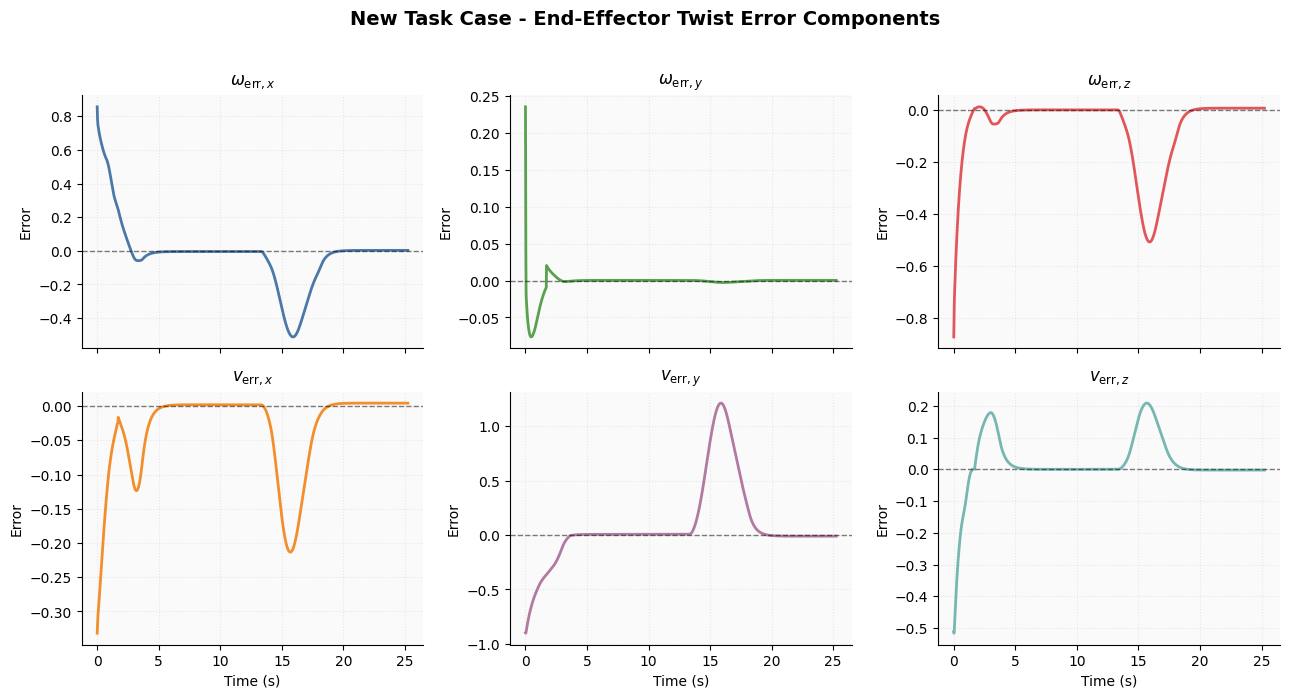

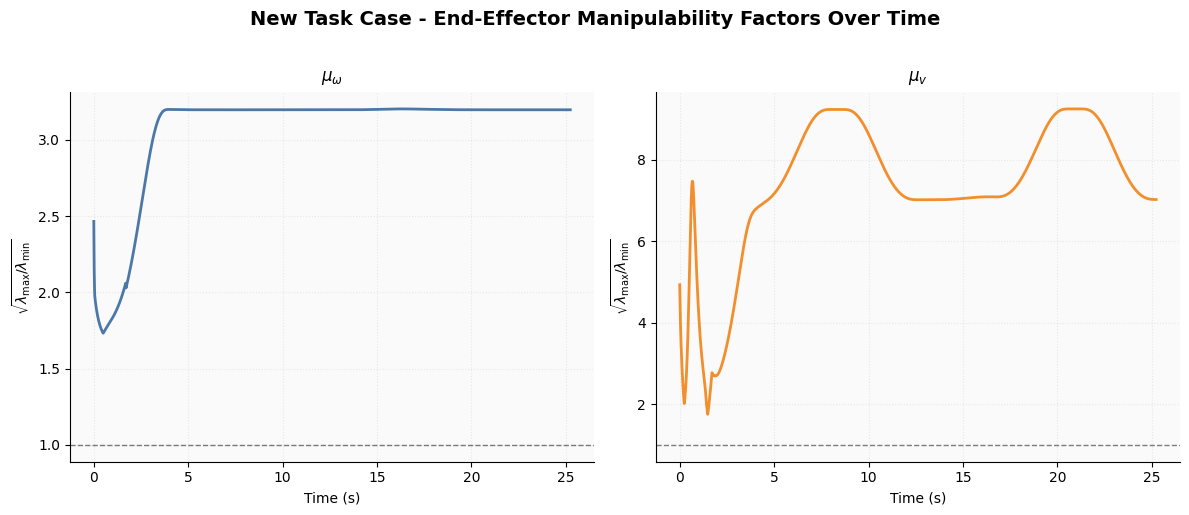

In [12]:
# New cube poses: different position and orientation (theta = yaw in rad)
theta_init = 0.82  # ~47 deg
theta_final = 2.63  # ~151 deg
# Cube start at (1.5, 0.5), goal at (-1, 0.75) — overwrites T_sci/T_scf from config
T_sci = np.array(
    [
        [np.cos(theta_init), -np.sin(theta_init), 0, 1.5],
        [np.sin(theta_init), np.cos(theta_init), 0, 0.5],
        [0, 0, 1, 0.025],
        [0, 0, 0, 1],
    ]
)
T_scf = np.array(
    [
        [np.cos(theta_final), -np.sin(theta_final), 0, -1.0],
        [np.sin(theta_final), np.cos(theta_final), 0, 0.75],
        [0, 0, 1, 0.025],
        [0, 0, 0, 1],
    ]
)

# Define initial conditions
actual_init_config = np.array(
    [0.25, -0.25, 0.820, 0.459, -0.227, 0.482, -1.294, 0.731, 0, 0, 0, 0, 0]
)
T_se_ref = np.array([[0, 0, 1, 0], [0, 1, 0, 0], [-1, 0, 0, 0.5], [0, 0, 0, 1]])

# Controller gains
K_p = 2.0 * np.eye(6)
K_i = 0.01 * np.eye(6)

# Run simulation and plotting
q_traj, X_err_traj, J_e_traj = run_simulation(
    actual_init_config, T_se_ref, T_sci, T_scf, K_p, K_i, k=1
)
np.savetxt("trajectories/new_task_case_trajectory.csv", q_traj, delimiter=",")
plot_X_err_traj(X_err_traj, "new_task_case_X_err_traj", "New Task Case")
plot_manipulability_factors(
    J_e_traj, "new_task_case_manipulability_factors", "New Task Case"
)